# Лабораторна робота №3: Розвідувальний аналіз та візуалізація даних

### Мета роботи


Провести повний цикл розвідувального аналізу даних (EDA) — від первинного огляду до аналітичних висновків. Результат роботи — структурований **EDA-дашборд**: Jupyter-ноутбук із координованими візуалізаціями, що утворюють цілісну картину датасету.


### Набір даних: Palmer Penguins

Набір даних містить морфологічні виміри 344 пінгвінів трьох видів (*Adelie*, *Chinstrap*, *Gentoo*) з архіпелагу Палмер в Антарктиці. Зібраний біологом Крістен Горман (Dr. Kristen Gorman) протягом 2007–2009 рр. у рамках програми довгострокового екологічного моніторингу LTER (*Long Term Ecological Research Network*).


**Опис колонок:**

| Колонка | Тип | Опис | Пропуски |
|---------|-----|------|----------|
| `species` | категоріальний | Вид пінгвіна: Adelie, Chinstrap, Gentoo | 0 |
| `island` | категоріальний | Острів: Biscoe, Dream, Torgersen | 0 |
| `bill_length_mm` | числовий | Довжина дзьоба (мм) | 2 |
| `bill_depth_mm` | числовий | Глибина (висота) дзьоба (мм) | 2 |
| `flipper_length_mm` | числовий | Довжина ласту (мм) | 2 |
| `body_mass_g` | числовий | Маса тіла (г) | 2 |
| `sex` | категоріальний | Стать: Male, Female | 11 |

### Підготовка середовища та завантаження даних

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

df = sns.load_dataset('penguins')
print(f'Дані завантажено: {df.shape}')

df.head()

Дані завантажено: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


---

## Огляд датасету

Проведіть структурний огляд датасету. Необхідно отримати повну картину даних до початку візуального аналізу.

**Вимоги:**

1. Виведіть загальну інформацію про датасет: кількість рядків, кількість колонок, типи даних кожної колонки, обсяг пам'яті.
2. Побудуйте таблицю пропущених значень: для кожної колонки покажіть кількість та відсоток пропусків. Відсортуйте за спаданням.
3. Обчисліть описову статистику для числових колонок. Поясніть у текстовій клітинці, що можна зрозуміти про дані лише з цієї таблиці (без графіків).
4. Для категоріальних колонок покажіть кількість унікальних значень та розподіл частот.

In [ ]:
print("Кількість рядків і колонок:", df.shape)
print("\nТипи даних:")
print(df.dtypes)

print("\nІнформація:")
df.info()

Кількість рядків і колонок: (344, 7)

Типи даних:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Інформація:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
missing = pd.DataFrame({
    'Кількість пропусків': df.isnull().sum(),
    'Відсоток (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing['Кількість пропусків'] > 0].sort_values(by='Відсоток (%)', ascending=False)
print(missing)

                   Кількість пропусків  Відсоток (%)
sex                                 11          3.20
bill_length_mm                       2          0.58
bill_depth_mm                        2          0.58
flipper_length_mm                    2          0.58
body_mass_g                          2          0.58


In [ ]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


**Інтерпретація описової статистики:**

*З описової статистики видно, що числові ознаки мають різні діапазони значень. Наприклад, довжина дзьоба (bill_length_mm) та маса тіла (body_mass_g) суттєво відрізняються між мінімальними та максимальними значеннями, що може свідчити про різницю між видами пінгвінів. Середні значення знаходяться приблизно посередині діапазону, що вказує на відносно рівномірний розподіл без сильних перекосів. Також видно наявність пропущених значень, оскільки кількість (count) менша за загальну кількість рядків.*

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


species:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

island:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

sex:
sex
Male      168
Female    165
Name: count, dtype: int64


---

## Розподіли ознак

Візуалізуйте розподіл кожної ознаки. Тип графіка має відповідати типу змінної.

**Вимоги:**

1. Побудуйте сітку графіків розподілу для всіх **числових** ознак (4 графіки). Для кожного числового графіка одночасно покажіть і форму розподілу, і оцінку щільності (KDE).
2. Побудуйте графіки частот для всіх **категоріальних** ознак (3 графіки).
3. Усі 7 графіків мають бути розміщені на одному зображенні за допомогою сітки підграфіків.
4. Кожен графік повинен мати заголовок, підписи осей, та зрозумілу колірну палітру.
5. У текстовій клітинці після графіків опишіть: які розподіли симетричні, які асиметричні, чи є ознаки можливих підгруп (мультимодальність), чи є потенційні викиди.

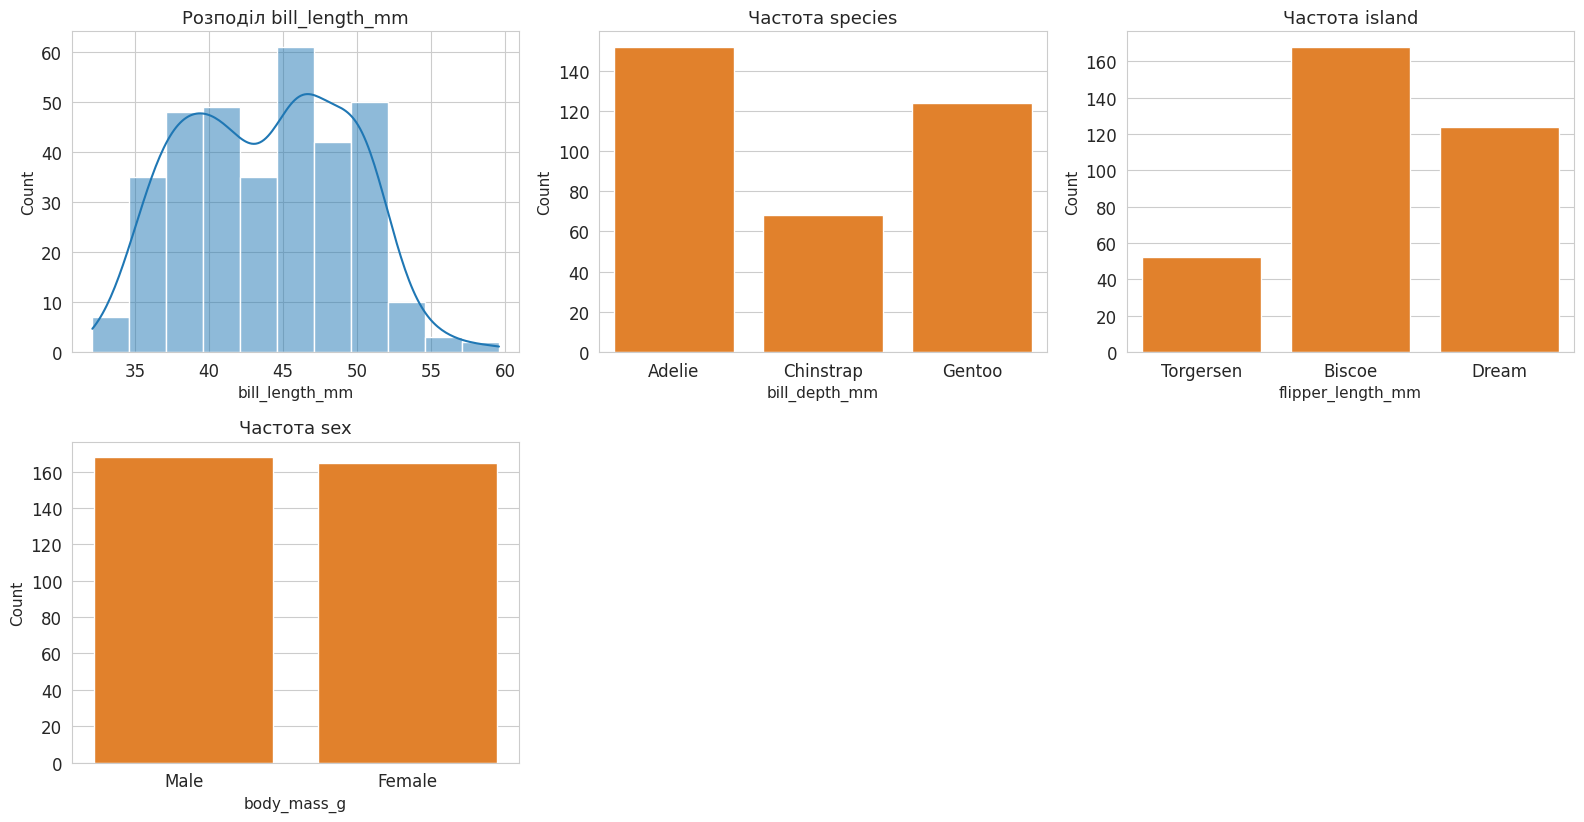

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# числовые и категориальные колонки
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
cat_cols = ['species', 'island', 'sex']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# --- ЧИСЛОВЫЕ (гистограммы + KDE) ---
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'Розподіл {col}')

# --- КАТЕГОРІАЛЬНІ (barplot) ---
for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[(i+1)//3, (i+1)%3])
    axes[(i+1)//3, (i+1)%3].set_title(f'Частота {col}')

# прибираємо зайві пусті графіки
for ax in axes.flat:
    if not ax.has_data():
        ax.set_visible(False)

plt.tight_layout()
plt.show()

**Інтерпретація розподілів:**

*Більшість числових ознак мають близький до нормального розподіл, однак спостерігається певна асиметрія, особливо для маси тіла (body_mass_g), що може свідчити про відмінності між видами пінгвінів. На деяких графіках помітні кілька піків, що вказує на наявність підгруп у даних. Категоріальні ознаки показують нерівномірний розподіл: деякі значення зустрічаються значно частіше за інші, наприклад певні види або острови. Також можливі окремі викиди серед числових значень, що потребують додаткового аналізу.*

---

## Порівняльний аналіз за групами

Порівняйте числові характеристики пінгвінів різних **видів**.

**Вимоги:**

1. Для кожної числової ознаки побудуйте графік, що одночасно показує:
   - розподіл значень усередині кожного виду
   - центральну тенденцію (медіану)
   - розкид (міжквартильний діапазон)
   - наявність викидів
2. Усі 4 порівняльних графіки мають бути на одному зображенні.
3. Поясніть у тексті: які ознаки найкраще розрізняють види? Чи є перекриття розподілів між видами?

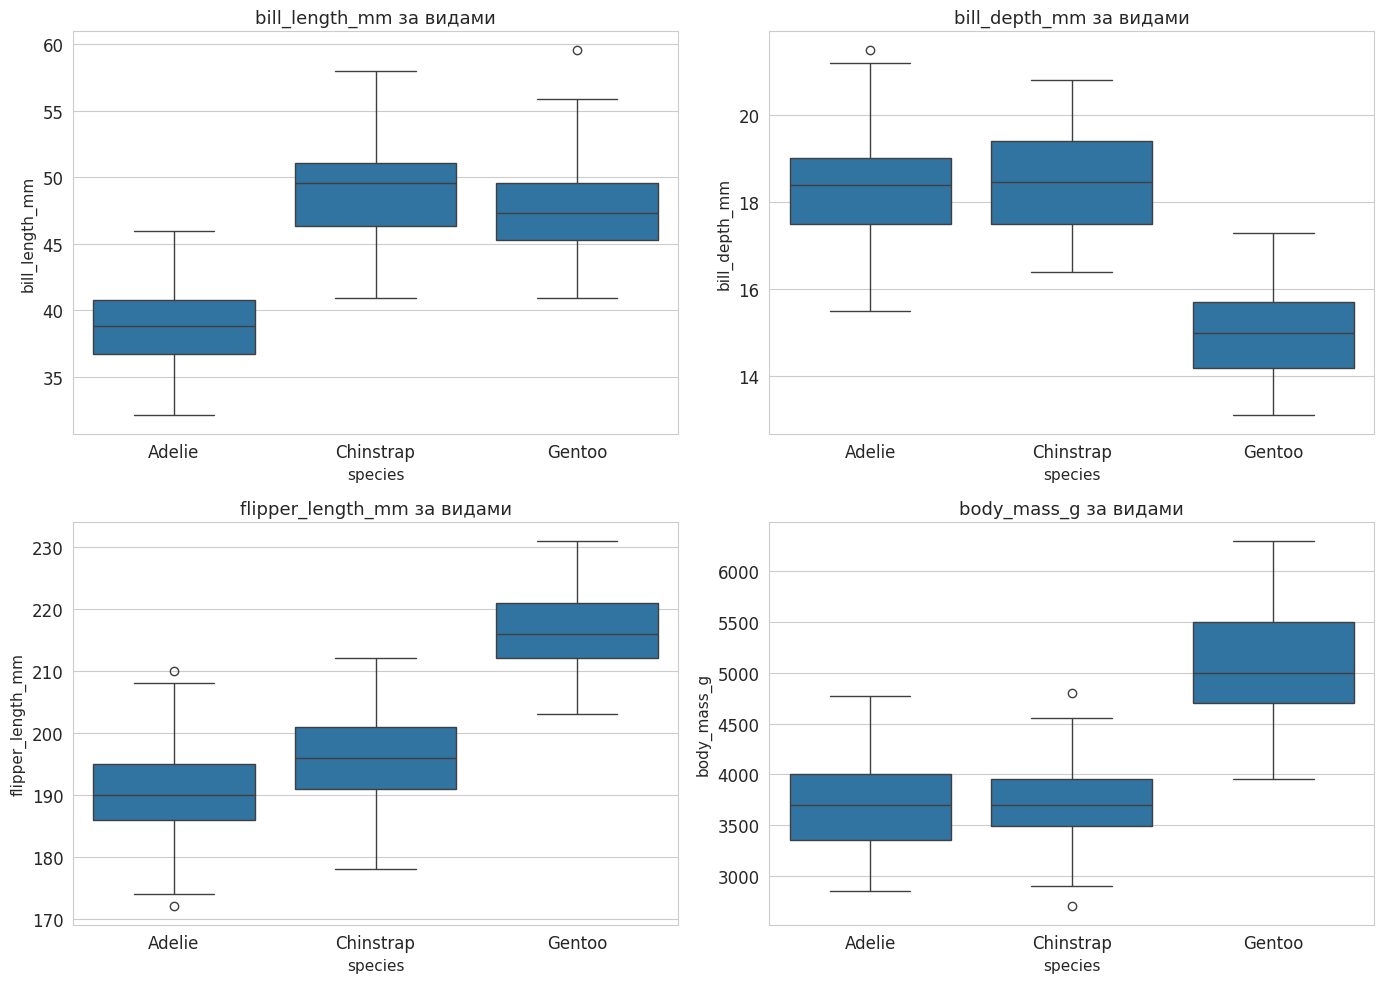

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

for i, col in enumerate(num_cols):
    sns.boxplot(x='species', y=col, data=df, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'{col} за видами')

plt.tight_layout()
plt.show()

**Інтерпретація порівняльного аналізу:**

*Порівняльний аналіз показав, що числові характеристики суттєво відрізняються між видами пінгвінів. Найбільш помітні відмінності спостерігаються у довжині ласт та масі тіла — ці ознаки добре розділяють види, особливо Gentoo, який має більші значення. Для деяких ознак, таких як глибина дзьоба, спостерігається часткове перекриття розподілів між видами, що ускладнює їх чітке розмежування. Також на графіках видно наявність викидів, що свідчить про індивідуальні особливості окремих особин. Загалом, найбільш інформативними для розрізнення видів є flipper_length_mm та body_mass_g.*

---

## Зв'язки між ознаками

Дослідіть парні залежності між числовими ознаками.

**Вимоги:**

1. Побудуйте матрицю діаграм розсіювання (*scatter plot matrix / sns pairplot *), де колір точок відображає вид пінгвіна. На діагоналі мають бути розподіли.
2. Оберіть **одну** найцікавішу пару ознак (за вашою оцінкою) та побудуйте для неї окремий детальний графік розсіювання. На ньому:
   - колір = вид
   - додайте лінію тренду для кожного виду окремо
3. Поясніть у тексті:
   - Які пари ознак мають найсильніший зв'язок?
   - Чи однаковий напрямок зв'язку для різних видів?

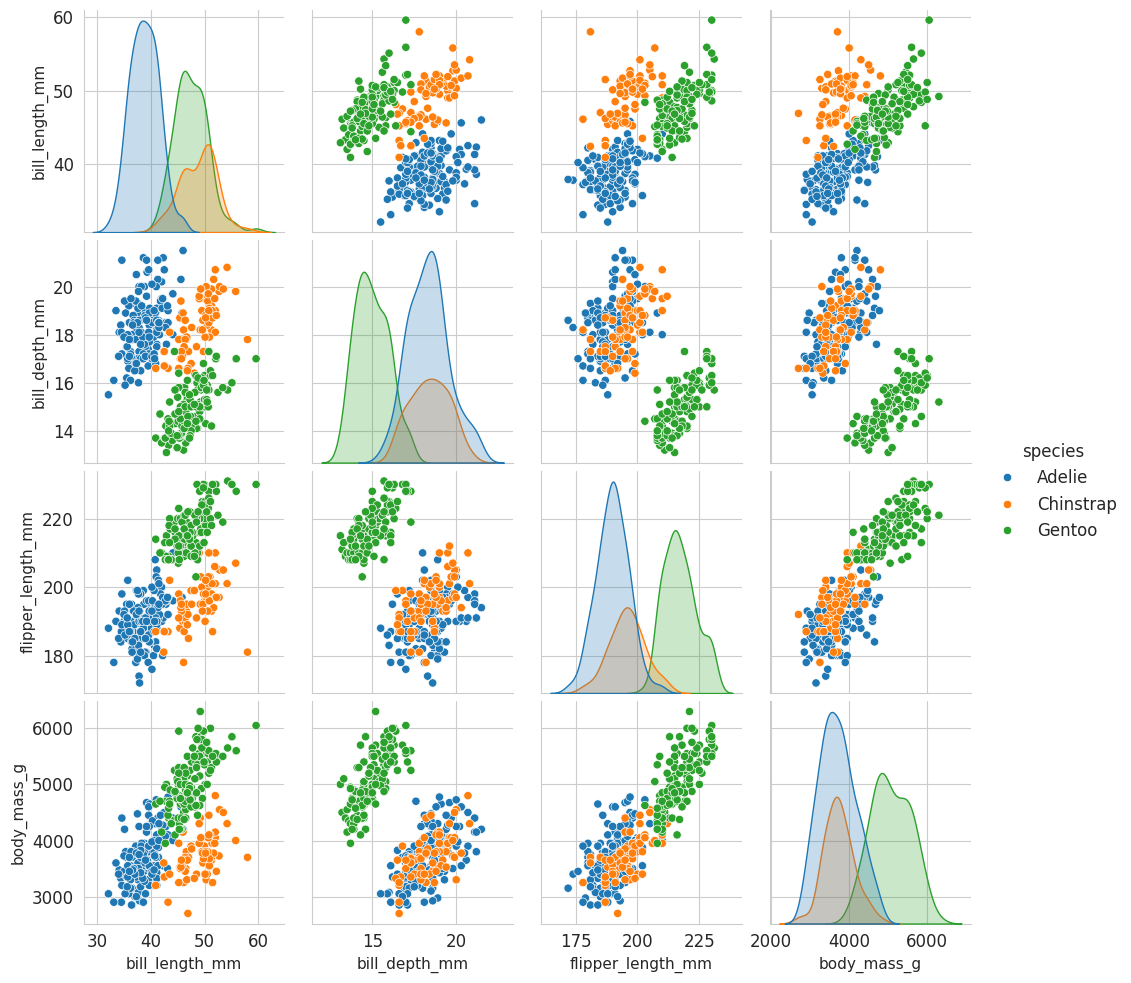

In [ ]:
sns.pairplot(df, hue='species')
plt.show()

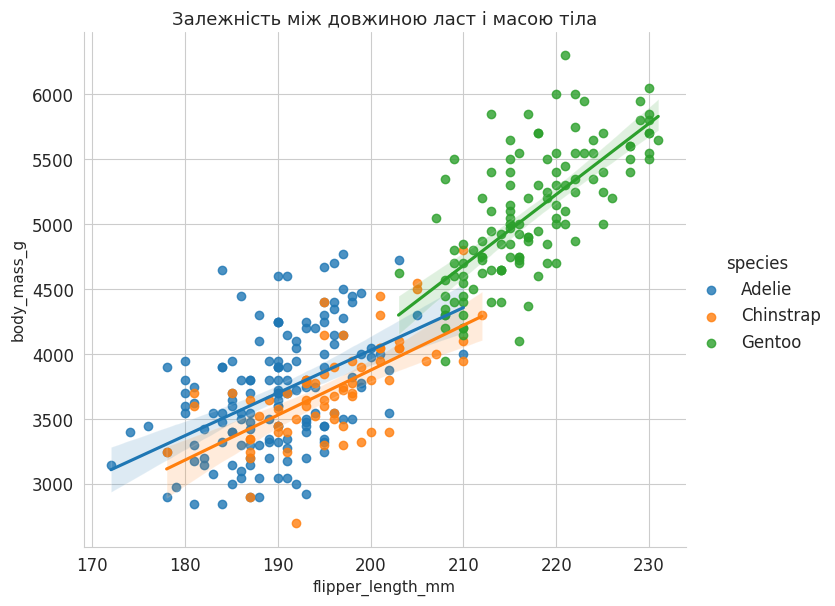

In [ ]:
sns.lmplot(
    data=df,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='species',
    height=6,
    aspect=1.2
)

plt.title('Залежність між довжиною ласт і масою тіла')
plt.show()

**Інтерпретація зв'язків:**

*Аналіз парних залежностей показав, що між деякими числовими ознаками існує чіткий зв’язок. Найсильніша залежність спостерігається між довжиною ласт (flipper_length_mm) та масою тіла (body_mass_g): зі збільшенням довжини ласт зростає і маса тіла. При цьому різні види пінгвінів формують окремі групи на графіку, що свідчить про їх відмінності. Напрямок зв’язку для всіх видів однаковий (позитивний), але значення відрізняються. Інші пари ознак мають слабший або менш виражений зв’язок.*

---

## Кореляційний аналіз

Обчисліть та візуалізуйте кореляції між числовими ознаками.

**Вимоги:**

1. Обчисліть матрицю кореляцій для всіх числових ознак.
2. Візуалізуйте матрицю кореляцій як теплову карту (*heatmap*) з числовими значеннями.
3. Обчисліть та візуалізуйте кореляційну матрицю **окремо для кожного виду** (3 теплові карти на одній фігурі).
4. У тексті поясніть:
   - Які пари ознак мають найсильнішу позитивну/негативну кореляцію?
   - Чи змінюються кореляції залежно від виду?

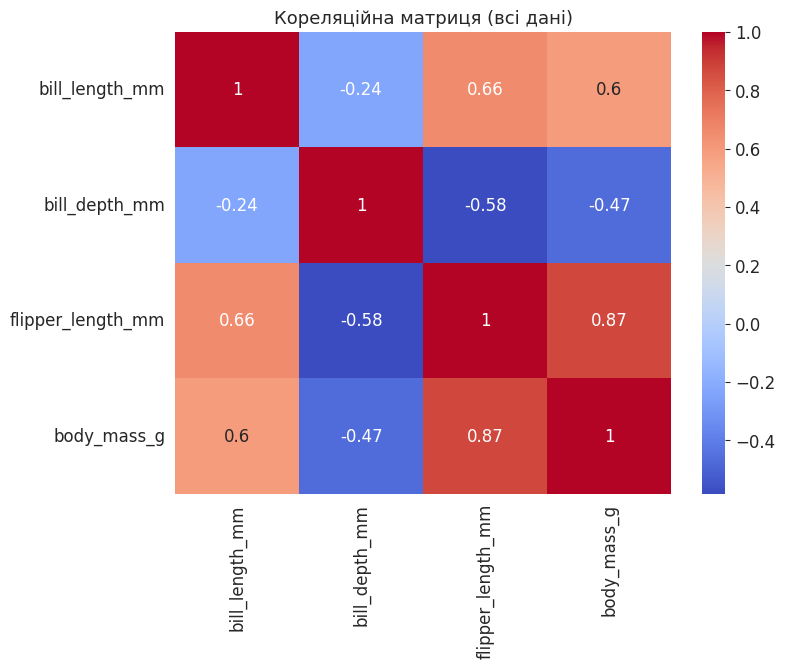

In [ ]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Кореляційна матриця (всі дані)')
plt.show()

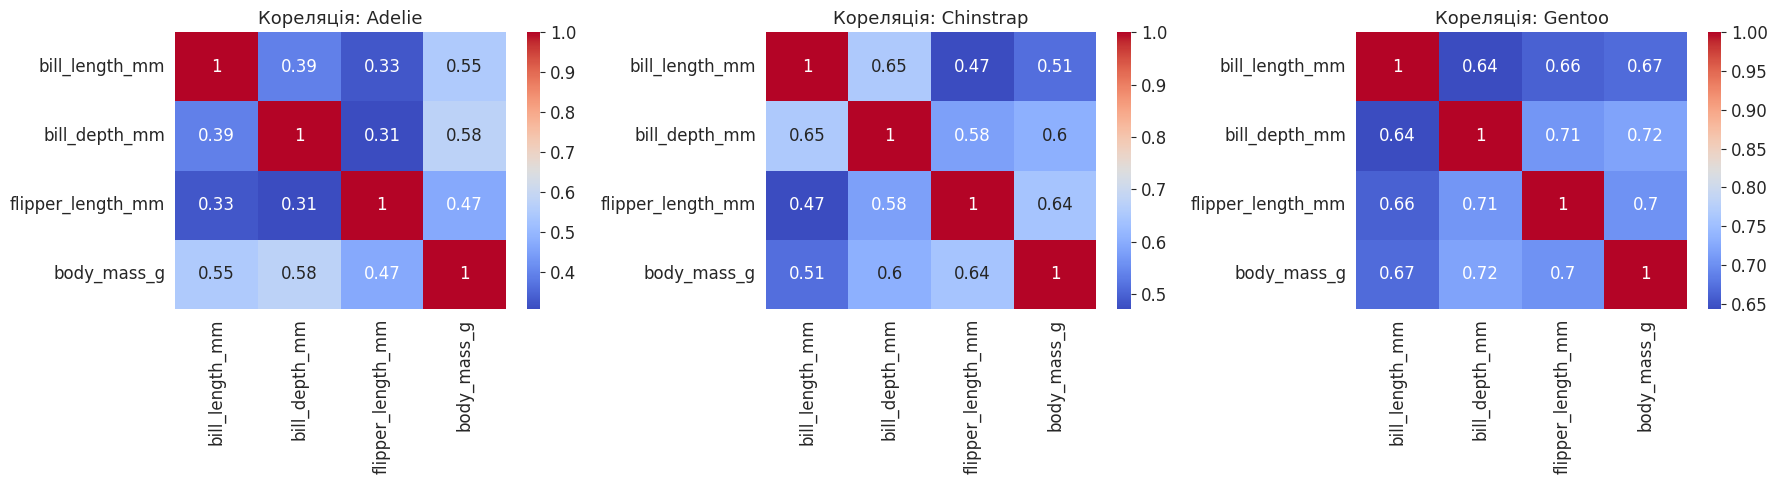

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, sp in enumerate(df['species'].unique()):
    subset = df[df['species'] == sp]
    corr = subset.select_dtypes(include='number').corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[i])
    axes[i].set_title(f'Кореляція: {sp}')

plt.tight_layout()
plt.show()

**Інтерпретація кореляцій:**

*Аналіз кореляційної матриці показав, що найсильніша позитивна кореляція спостерігається між довжиною ласт (flipper_length_mm) та масою тіла (body_mass_g), що свідчить про прямий зв’язок між цими ознаками. Інші ознаки мають слабші або помірні кореляції. При розгляді окремо по видах видно, що загальна тенденція зберігається, однак сила зв’язків може відрізнятися. Це означає, що залежності між ознаками частково залежать від виду пінгвіна.*

---

## Аналітичний звіт

Підсумуйте результати EDA у структурованому тексті.

**Вимоги:**

Напишіть аналітичний звітіз такою структурою:

1. **Ключові знахідки**: Перерахуйте найважливіші патерни, які ви виявили в ході аналізу. Додайте найважливіші графіки (мінімум 3) з роботи на фінальну фізуалізацію (matplotlib.gridspec або аналогічним чином), які підкріплюють знахідки

2. **Гіпотези для подальшого дослідження**: Сформулюйте гіпотези, які можна перевірити статистичними тестами або моделями машинного навчання. Наприклад: *«ОЗНАКА Х може бути достатньою ознакою для класифікації виду%»* — для перевірки потрібен класифікатор.

3. **Обмеження аналізу**: Які аспекти датасету залишились непроаналізованими? Які додаткові дані покращили б дослідження?

### Аналітичний звіт

#### 1. Ключові знахідки

*У ході розвідувального аналізу даних було виявлено, що числові характеристики пінгвінів суттєво відрізняються залежно від виду. Найбільш інформативними ознаками для розрізнення видів є довжина ласт (flipper_length_mm) та маса тіла (body_mass_g), які мають чіткий розподіл та мінімальне перекриття між групами. Також було встановлено сильну позитивну кореляцію між цими ознаками. Інші характеристики, такі як довжина та глибина дзьоба, мають більший ступінь перекриття між видами. Категоріальні змінні, зокрема острів проживання, також показують нерівномірний розподіл між видами. Загалом дані мають зрозумілу структуру та дозволяють ефективно аналізувати відмінності між групами.*

#### 2. Гіпотези для подальшого дослідження

*Можна висунути гіпотезу, що довжина ласт та маса тіла є достатніми ознаками для класифікації виду пінгвіна. Також можна припустити, що існує лінійна залежність між масою тіла та довжиною ласт для всіх видів. Інша гіпотеза полягає в тому, що острів проживання впливає на фізичні характеристики пінгвінів. Для перевірки цих гіпотез можна застосувати методи машинного навчання або статистичні тести.*

#### 3. Обмеження аналізу

*Основним обмеженням аналізу є невеликий розмір вибірки та наявність пропущених значень у деяких ознаках. Також у наборі даних відсутні додаткові фактори, які можуть впливати на характеристики пінгвінів, наприклад вік, умови середовища або харчування. Крім того, аналіз базується лише на візуальних та описових методах без використання складних статистичних моделей, що може обмежувати точність висновків.*